# Trabalho 2 — Processamento de Imagens

Implementa os 4 itens:

1. Filtragem no domínio da frequência: Gaussiano e Butterworth, passa-baixas e
   passa-altas, e aguçamento via passa-altas gaussiano.
2. Extração de componentes conectados via dilatação morfológica.
3. Envoltório convexo (convex hull) via transformada Hit-or-Miss.
4. Segmentação por detecção de bordas.

Toda a lógica de processamento está em `imgproc/`. `cv2` é usado **apenas** para ler e salvar
arquivo (`imgproc/io_utils.py`).


In [1]:
import sys, os, time
sys.path.insert(0, os.getcwd())

import numpy as np

from imgproc import io_utils as io
from imgproc import freq_filters as ff
from imgproc import connected_components as cc
from imgproc import convex_hull as ch
from imgproc import edges as ce

IMG_DIR = "imgs"
np.set_printoptions(suppress=True)


## Item 1 — Filtragem no domínio da frequência

Fórmulas:
- GLPF(Função Gaussiana passa-baixa): `H = exp(-D²/(2·D0²))`
- GHPF(Função Gaussiana passa-alta): `H = 1 - GLPF`
- BLPF(Função Butterworth passa-baixa): `H = 1/(1+(D/D0)^(2n))`
- BHPF(Função Butterworth passa-alta): `H = 1/(1+(D0/D)^(2n))`


[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.406] global grfmt_tiff.cpp:123 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

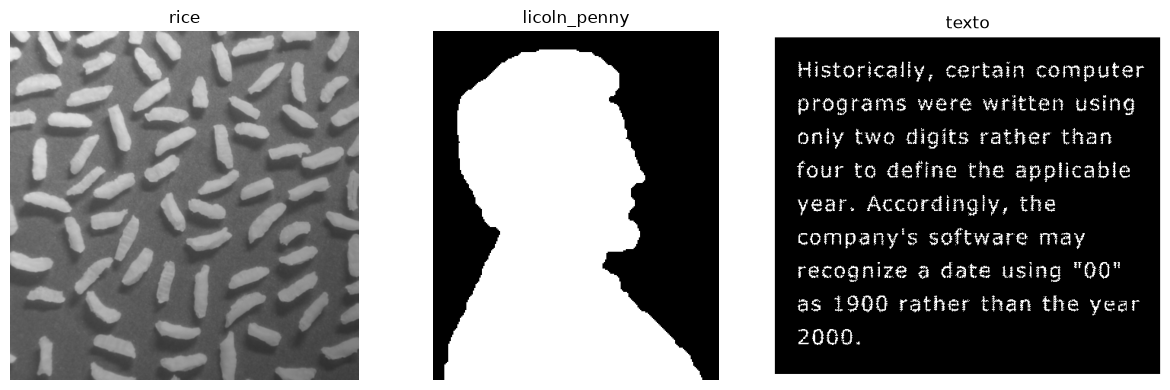

In [2]:
imgs_freq = {
    "rice": io.load_image(f"{IMG_DIR}/rice.tif"),
    "licoln_penny": io.load_image(f"{IMG_DIR}/licoln_penny.tif"),
    "texto": io.load_image(f"{IMG_DIR}/texto.tif"),
}
io.show_grid(list(imgs_freq.values()), titles=list(imgs_freq.keys()))


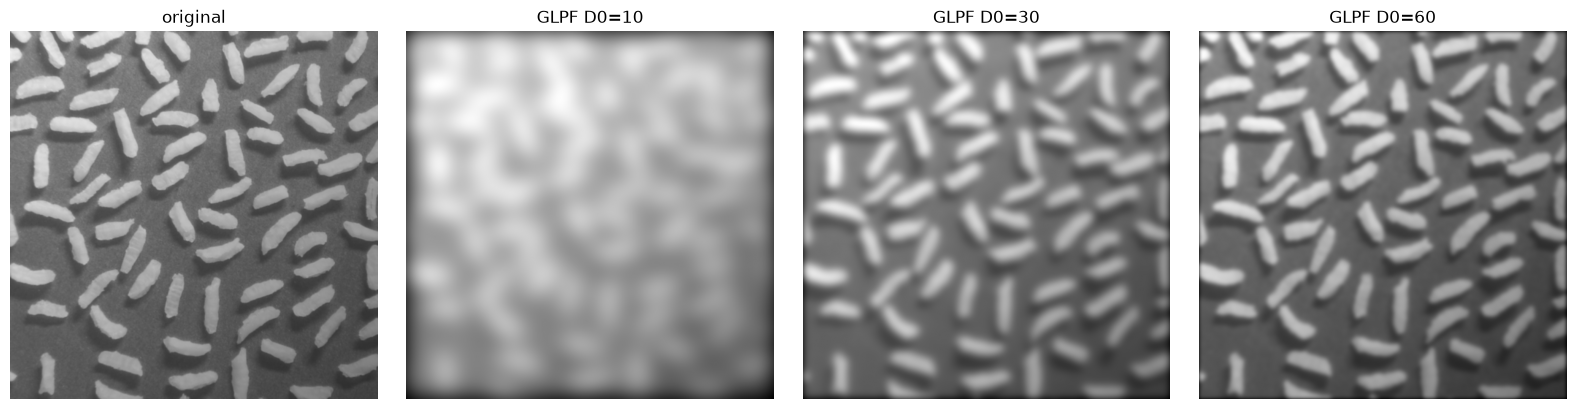

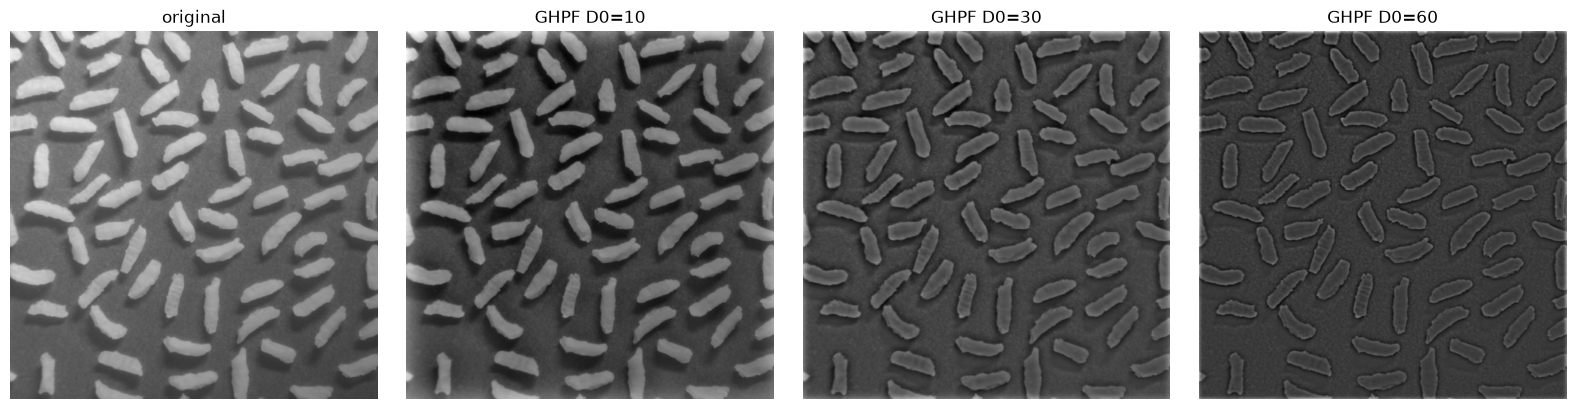

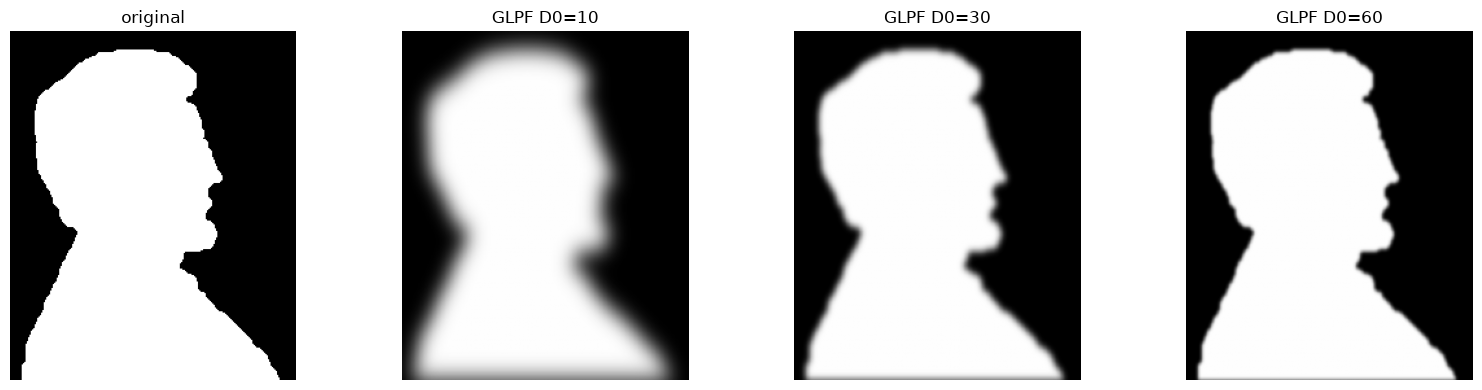

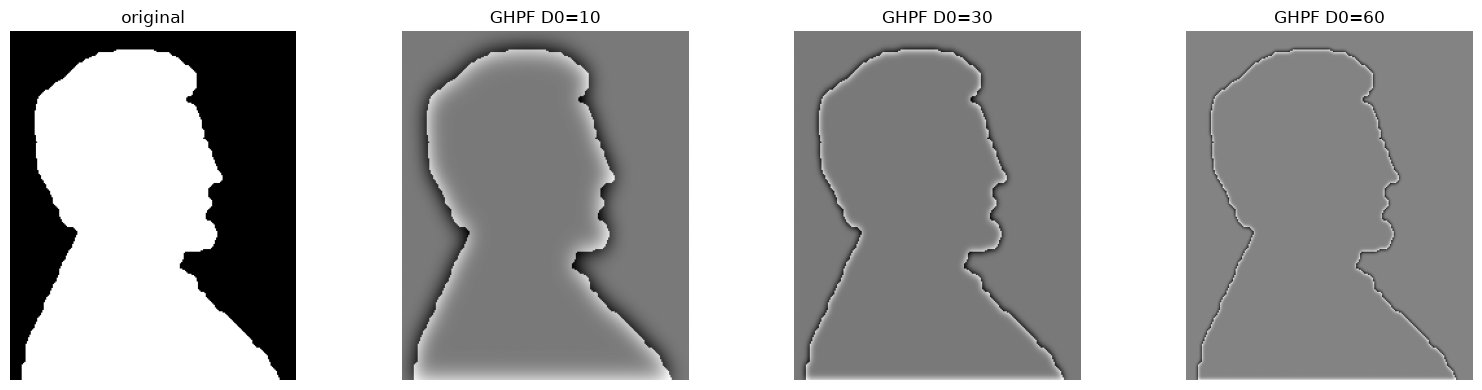

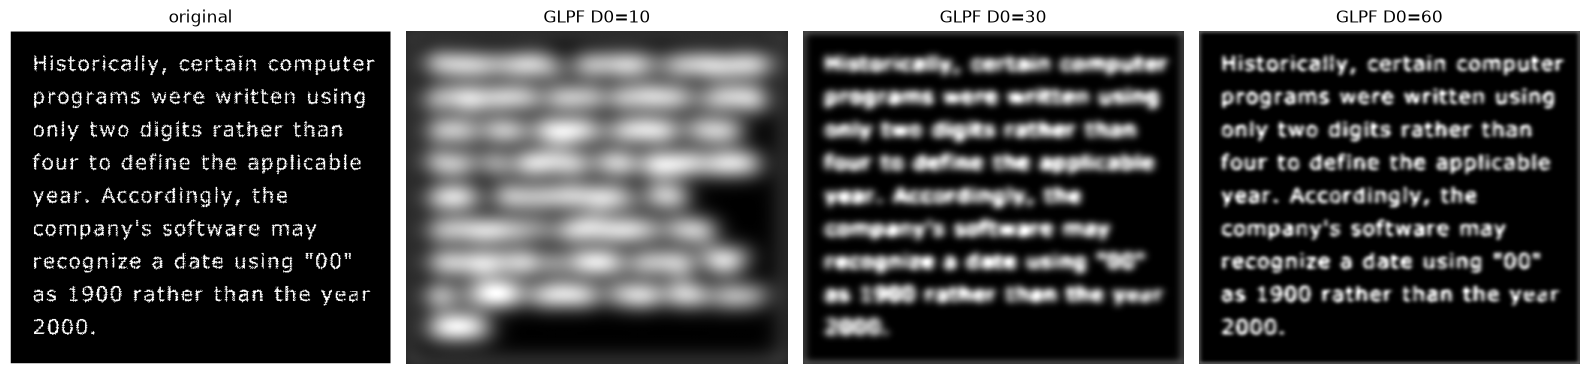

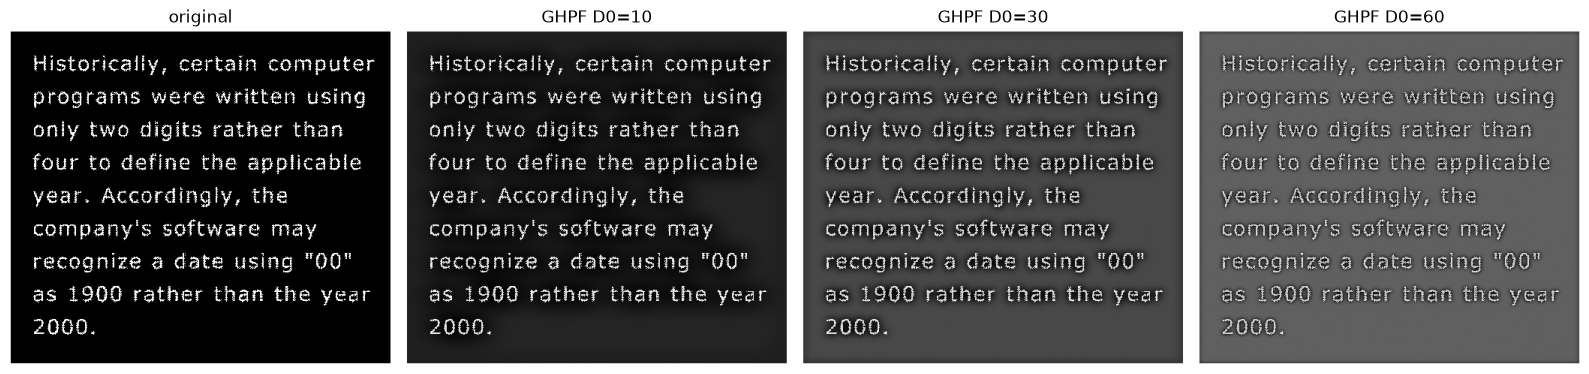

In [3]:
# Gaussiano passa-baixas e passa-altas, variando D0
D0_list = [10, 30, 60]
for name, img in imgs_freq.items():
    lp_results = [img] + [ff.gaussian_filter(img, D0) for D0 in D0_list]
    hp_results = [img] + [ff.gaussian_filter(img, D0, highpass=True) for D0 in D0_list]
    io.show_grid(lp_results, titles=["original"] + [f"GLPF D0={d}" for d in D0_list])
    io.show_grid(hp_results, titles=["original"] + [f"GHPF D0={d}" for d in D0_list])


O parâmetro $D_0$ funciona como um "raio de corte" que decide a quantidade de detalhes visuais que será afetada. No filtro passa-baixas (usado para borrar a imagem), um $D_0$ pequeno elimina quase todos os detalhes e gera um borrão forte, enquanto um $D_0$ grande deixa os detalhes passarem, mantendo o resultado quase igual ao original. Já no filtro passa-altas (usado para destacar bordas), a lógica se inverte: um $D_0$ pequeno mantém bastante informação visível com contornos mais grossos, mas um $D_0$ grande bloqueia o fundo e as cores quase totalmente, resultando em uma imagem bem escura onde apenas as linhas e texturas mais finas aparecem.

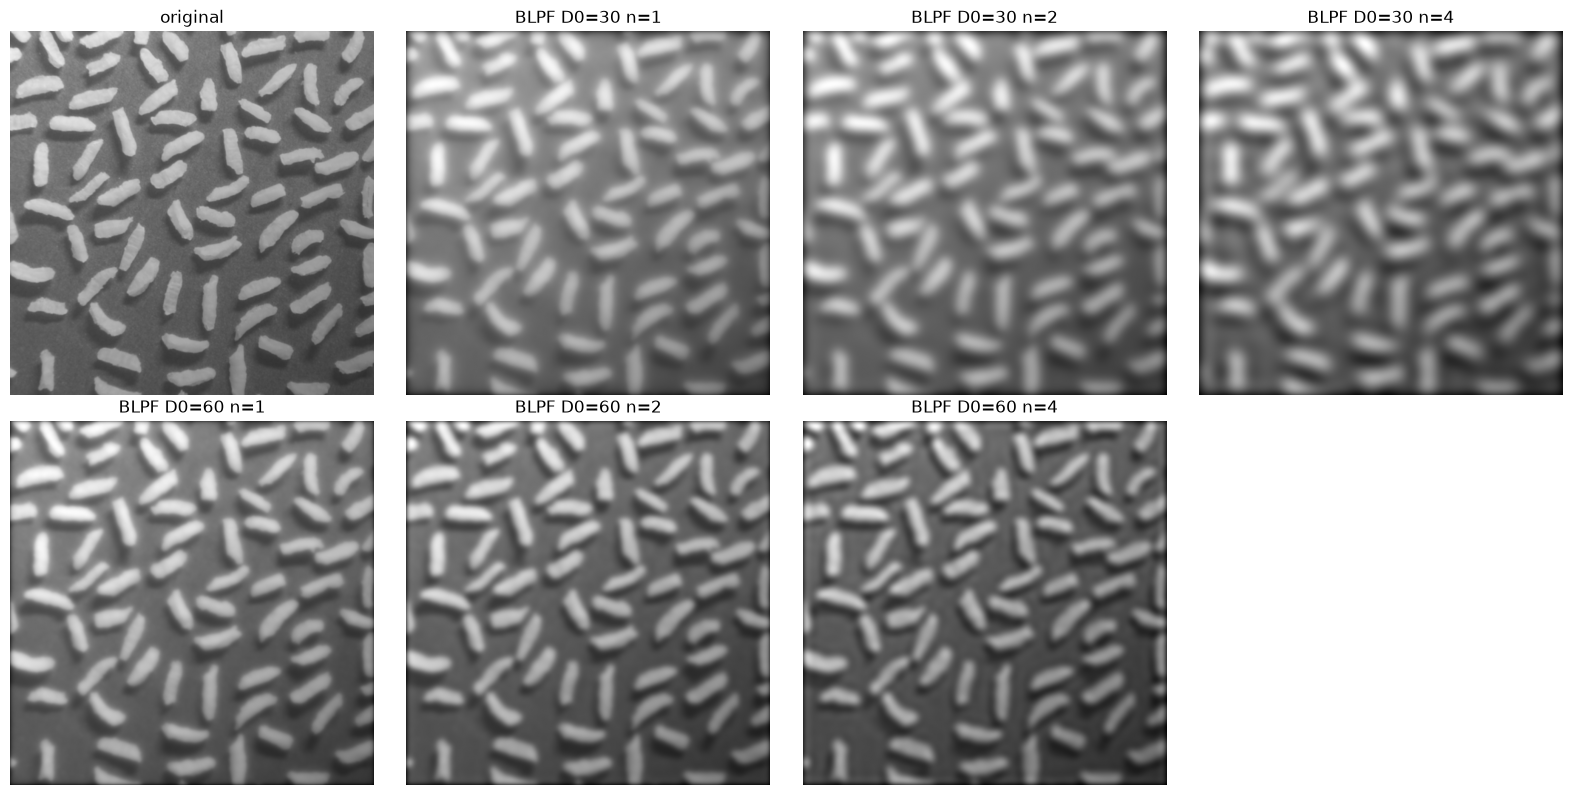

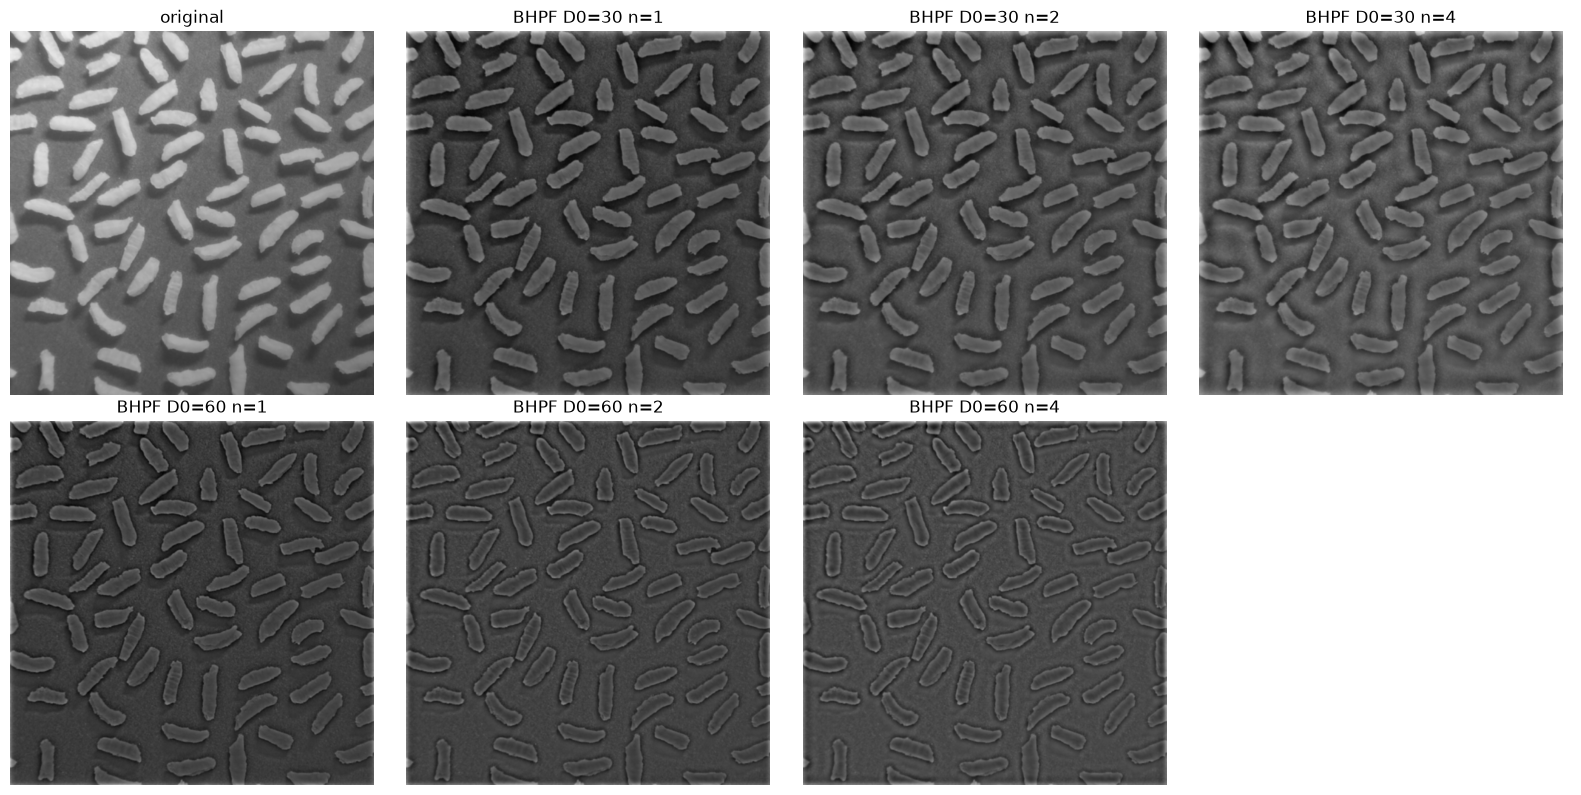

In [4]:
# Butterworth passa-baixas e passa-altas, variando D0 e n
D0_bw = [30, 60]
n_bw = [1, 2, 4]
img = imgs_freq["rice"]
results, titles = [img], ["original"]
for D0 in D0_bw:
    for n in n_bw:
        results.append(ff.butterworth_filter(img, D0, n))
        titles.append(f"BLPF D0={D0} n={n}")
io.show_grid(results, titles=titles, cols=4)

results, titles = [img], ["original"]
for D0 in D0_bw:
    for n in n_bw:
        results.append(ff.butterworth_filter(img, D0, n, highpass=True))
        titles.append(f"BHPF D0={D0} n={n}")
io.show_grid(results, titles=titles, cols=4)


No filtro Butterworth, o parâmetro $D_0$ define a quantidade de detalhes bloqueados, seguindo a mesma lógica do filtro Gaussiano. O grande diferencial é o parâmetro $n$, que controla a suavidade dessa transição. Se você usar um $n$ baixo (próximo a 1), o corte é suave e a imagem fica sem defeitos visuais. Porém, se aumentar bastante o $n$ (para 4 ou mais), o corte se torna muito brusco (assemelhando-se ao Filtro Ideal), o que acaba gerando o indesejado efeito de ringing — pequenas "ondas" ou anéis ao redor das bordas e transições da imagem. No fim, é uma troca direta: quanto mais agressivo e preciso for o corte da frequência, mais artefatos visuais acabarão aparecendo no resultado.

[ WARN:0@5.354] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


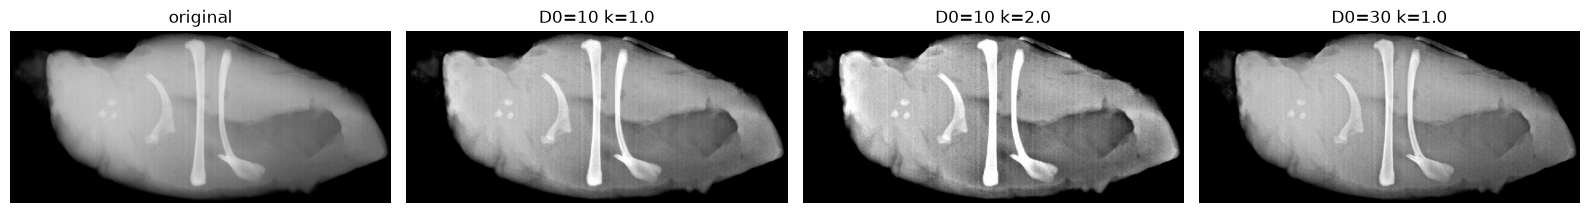

In [5]:
# Aguçamento via passa-altas gaussiano: g = f + k*GHPF(f, D0)
img = io.load_image(f"{IMG_DIR}/Fig0918(a)(Chickenfilet with bones).tif")
sharpened = [img]
titles = ["original"]
for D0, k in [(10, 1.0), (10, 2.0), (30, 1.0)]:
    sharpened.append(ff.highboost_sharpen(img, D0=D0, k=k))
    titles.append(f"D0={D0} k={k}")
io.show_grid(sharpened, titles=titles)


O efeito da intensidade (k): Se compararmos as duas imagens com D0​=10, fica nítido que aumentar o valor de k de 1.0 para 2.0 "estoura" o contraste. Na imagem com k=2.0, os ossos ficam excessivamente brancos (saturados) e os contornos muito mais duros e escuros. Isso comprova visualmente que o k atua como um multiplicador de força, controlando o quão agressivo será o destaque das bordas.

O efeito do raio de corte (D0​): Se compararmos as imagens que usam o mesmo peso (k=1.0), mas com raios diferentes, notamos uma mudança na espessura dos detalhes realçados. Com o D0​ menor (10), o aguçamento é mais global e espesso, iluminando uma área maior ao redor dos ossos e destacando os tecidos da carne de forma mais bruta. Quando o D0​ aumenta para 30, o filtro passa a atuar apenas nos extremos; o realce se torna muito mais sutil e focado apenas nos microdetalhes (as linhas mais finas da imagem), fazendo com que o resultado geral pareça bem mais próximo da foto original, porém levemente mais nítido.

## Item 2 — Componentes conectados via dilatação morfológica (otimizado)




componentes: 159   tempo: 8.11s


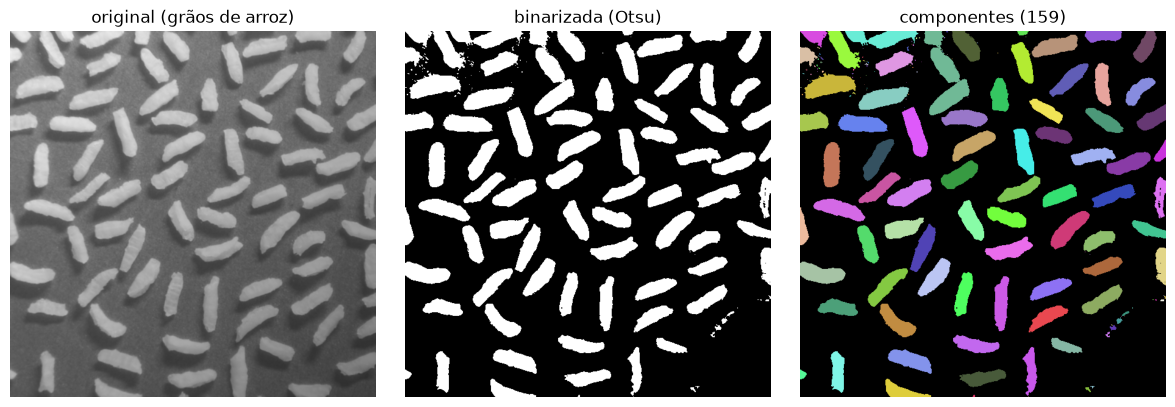

In [6]:
rice_cc = io.load_image(f"{IMG_DIR}/rice.tif")
rice_cc_bin = io.binarize(rice_cc)

t0 = time.time()
labels_rice_cc, n_rice_cc = cc.extract_components(rice_cc_bin)
dt = time.time() - t0
print(f"componentes: {n_rice_cc}   tempo: {dt:.2f}s")

io.show_grid(
    [rice_cc, rice_cc_bin, cc.colorize(labels_rice_cc)],
    titles=["original (grãos de arroz)", "binarizada (Otsu)", f"componentes ({n_rice_cc})"],
)


O algoritmo detectou 159 componentes na imagem, um número inflado pela presença de 82 pequenos ruídos gerados durante a binarização. Os 77 componentes restantes representam os grãos reais, que foram identificados e coloridos individualmente com sucesso quando estavam isolados. Contudo, como o método se baseia estritamente na conectividade dos pixels, ele não consegue distinguir objetos encostados, o que acabou fundindo grãos adjacentes em blocos únicos e com áreas muito acima da média.

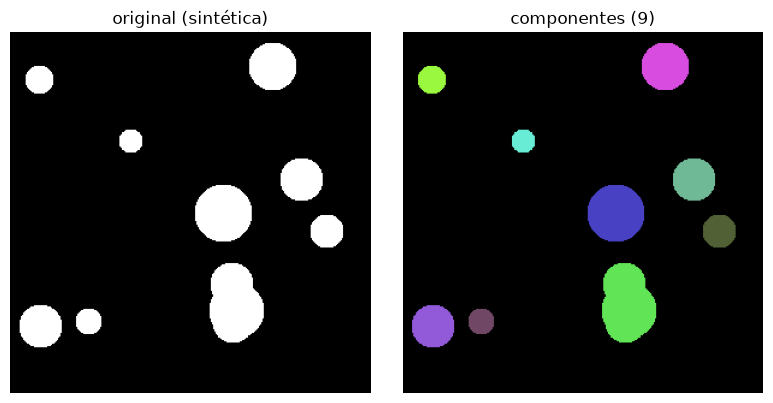

In [7]:
# Segundo teste: círculos sintéticos sobrepostos ao estilo do slide 46
rng = np.random.default_rng(0)
canvas = np.zeros((300, 300), dtype=np.uint8)
yy, xx = np.mgrid[0:300, 0:300]
for _ in range(12):
    cy, cx, r = rng.integers(20, 280), rng.integers(20, 280), rng.integers(10, 25)
    canvas[(yy - cy) ** 2 + (xx - cx) ** 2 < r ** 2] = 255

labels_circ, n_circ = cc.extract_components(canvas)
io.show_grid(
    [canvas, cc.colorize(labels_circ)],
    titles=["original (sintética)", f"componentes ({n_circ})"],
)


Neste teste com imagens sintéticas, o código foi programado para desenhar 12 círculos aleatórios, mas o algoritmo detectou e coloriu apenas 9 componentes. Analisando o mapa de cores gerado, o motivo é evidente: os círculos que acabaram sendo desenhados sobrepostos ou encostados (como os agrupamentos verde-claro e roxo na parte inferior) foram fundidos e receberam a mesma cor. Esse resultado isola e ilustra perfeitamente a característica do método de extração por dilatação morfológica, que rotula as regiões baseando-se apenas na conectividade dos pixels, incapaz de separar objetos logicamente distintos que se tocam na imagem.


## Item 3 — Envoltório convexo via Hit-or-Miss


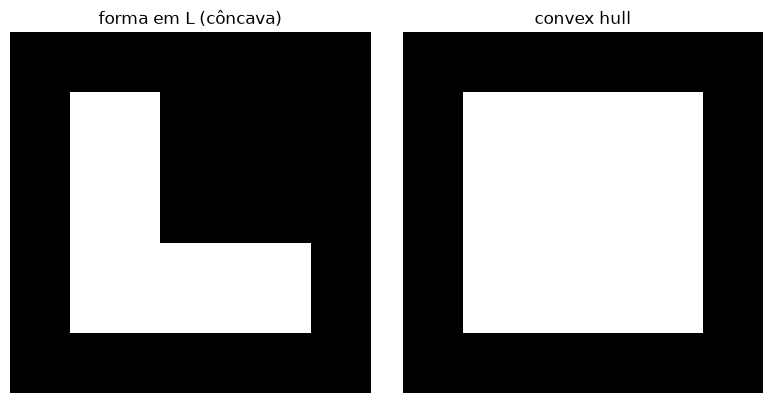

In [8]:
# Validação didática: forma em L (canto côncavo real) -> hull deve virar um retângulo sólido
lshape = np.zeros((12, 12), dtype=np.uint8)
lshape[2:10, 2:5] = 255
lshape[7:10, 2:10] = 255
hull_l = ch.convex_hull_binary(lshape)
io.show_grid([lshape, hull_l], titles=["forma em L (côncava)", "convex hull"])
assert hull_l.sum() > lshape.sum(), "hull deveria crescer para preencher o canto"


tempo hull: 4.29s   componentes: 17


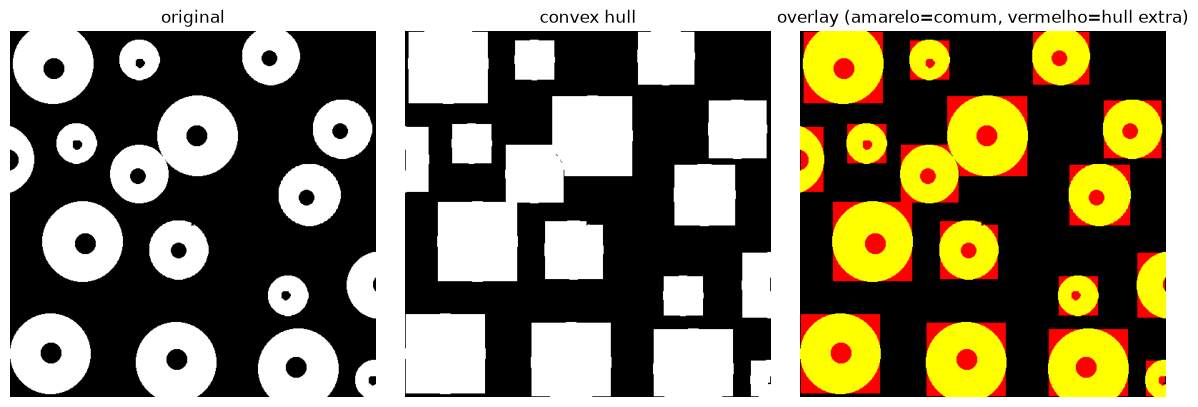

In [9]:
region = io.load_image(f"{IMG_DIR}/region-filling.tif")
region_bin = io.binarize(region)
labels_region, n_region = cc.extract_components(region_bin)

t0 = time.time()
hull_region = ch.convex_hull_per_component(region_bin, labels_region, n_region)
print(f"tempo hull: {time.time()-t0:.2f}s   componentes: {n_region}")

overlay = np.zeros((*region_bin.shape, 3), dtype=np.uint8)
overlay[..., 0] = hull_region        # hull em vermelho
overlay[..., 1] = region_bin         # original em verde -> sobreposição fica amarela
io.show_grid([region_bin, hull_region, overlay],
             titles=["original", "convex hull", "overlay (amarelo=comum, vermelho=hull extra)"])


A imagem de saída ilustra perfeitamente o comportamento do envoltório convexo (convex hull), que tem como objetivo encontrar o menor conjunto convexo que contenha todo o objeto original, "esticando" a estrutura para remover quaisquer reentrâncias. Como a imagem de entrada é composta por anéis (formas que quebram a regra de convexidade devido ao buraco central e às curvas), o algoritmo precisou adicionar massa para torná-los convexos. A sobreposição (overlay) evidencia exatamente essa ação: a cor vermelha mostra que o método preencheu completamente os vazios internos e expandiu os contornos arredondados até formarem blocos sólidos com cantos retos, enquanto a área amarela comprova que os pixels da estrutura original foram integralmente preservados dentro dessa nova "caixa" convexa.

## Item 4 — Segmentação por detecção de bordas (Canny)




pixels de borda: 122


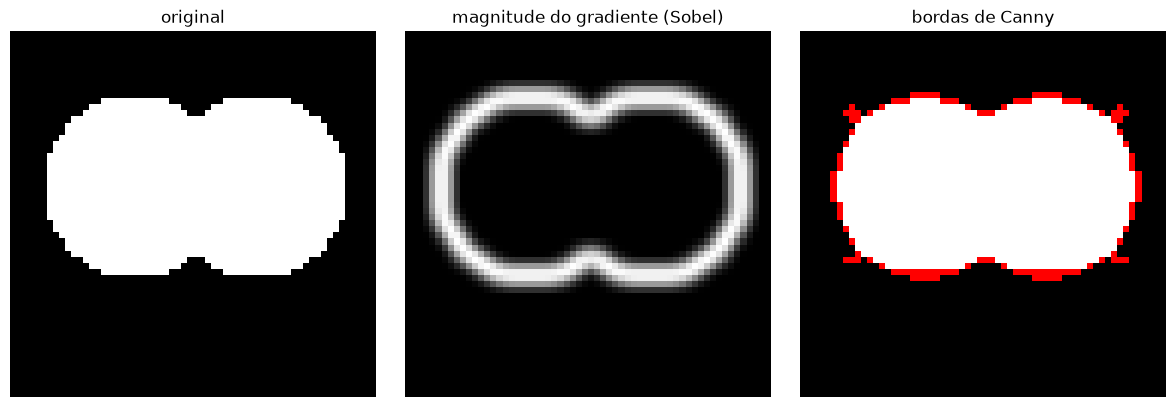

In [ ]:
# Caso sintético: dois círculos encostados
yy, xx = np.mgrid[0:60, 0:60]
c1 = (yy - 25) ** 2 + (xx - 20) ** 2 < 15 ** 2
c2 = (yy - 25) ** 2 + (xx - 40) ** 2 < 15 ** 2
touching = ((c1 | c2) * 255).astype(np.uint8)

edges_touch, mag_touch, _ = ce.canny(touching)
print("pixels de borda:", int((edges_touch > 0).sum()))

rgb = np.stack([touching] * 3, axis=-1)
overlay_touch = rgb.copy()
overlay_touch[edges_touch > 0] = [255, 0, 0]
io.show_grid(
    [touching, io.to_uint8(mag_touch), overlay_touch],
    titles=["original", "magnitude do gradiente (Sobel)", "bordas de Canny"],
)


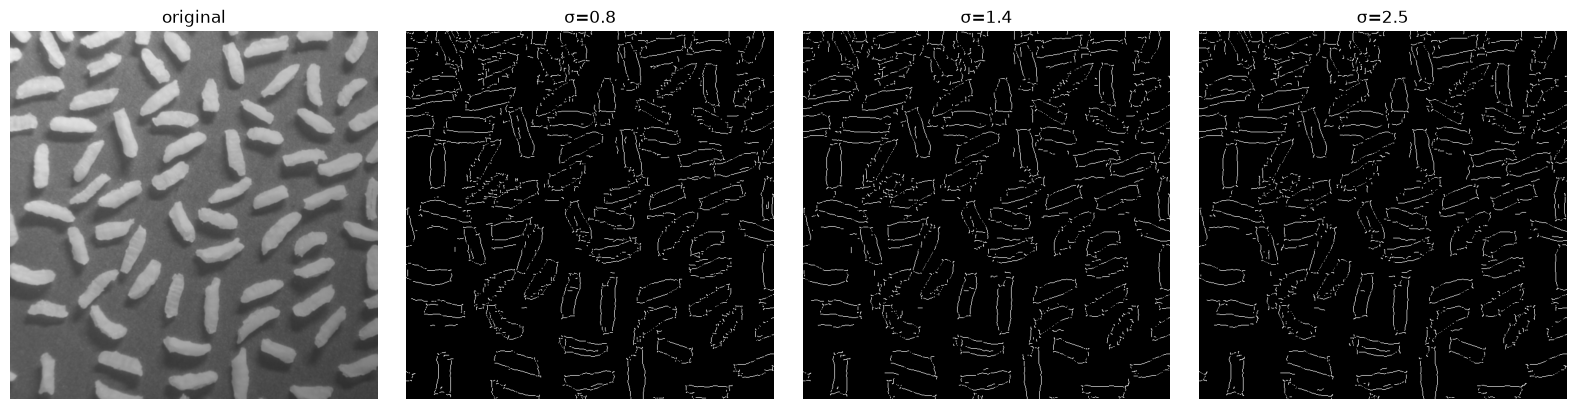

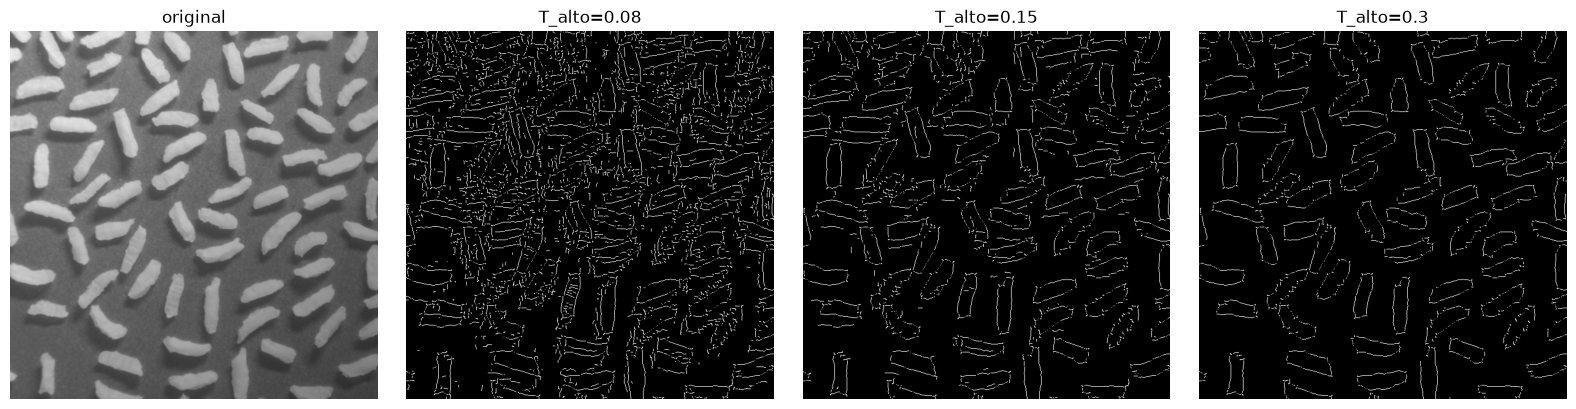

In [ ]:
rice = io.load_image(f"{IMG_DIR}/rice.tif")

sigma_list = [0.8, 1.4, 2.5]
results, titles = [rice], ["original"]
for sigma in sigma_list:
    edges_s, _, _ = ce.canny(rice, sigma=sigma)
    results.append(edges_s)
    titles.append(f"σ={sigma}")
io.show_grid(results, titles=titles)

high_list = [0.08, 0.15, 0.30]
results, titles = [rice], ["original"]
for high in high_list:
    edges_h, _, _ = ce.canny(rice, high_ratio=high, low_ratio=high / 2.5)
    results.append(edges_h)
    titles.append(f"T_alto={high}")
io.show_grid(results, titles=titles)


O parâmetro $\sigma$ controla a suavização inicial: valores baixos preservam os detalhes finos (incluindo ruídos), enquanto valores altos "limpam" a imagem, mas acabam borrando e fundindo bordas próximas. Já o limiar $T_{alto}$ atua na validação final: se for muito baixo, acaba aceitando qualquer textura ou gradiente fraco como borda; se for alto, exige uma transição de intensidade muito mais brusca, preservando apenas os contornos externos limpos e bem definidos.


[ WARN:0@46.687] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


pixels de borda: 4484


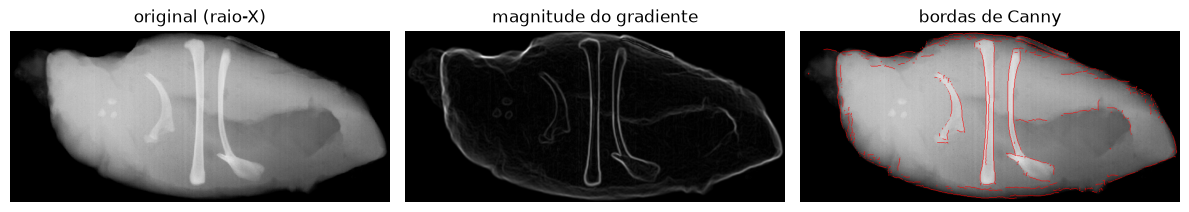

In [ ]:
# agora mostrando detecção de bordas direto no grayscale (sem binarizar).
chicken = io.load_image(f"{IMG_DIR}/Fig0918(a)(Chickenfilet with bones).tif")
edges_chicken, mag_chicken, _ = ce.canny(chicken, sigma=1.4, low_ratio=0.05, high_ratio=0.15)
print("pixels de borda:", int((edges_chicken > 0).sum()))

rgb_chicken = np.stack([chicken] * 3, axis=-1)
overlay_chicken = rgb_chicken.copy()
overlay_chicken[edges_chicken > 0] = [255, 0, 0]
io.show_grid(
    [chicken, io.to_uint8(mag_chicken), overlay_chicken],
    titles=["original (raio-X)", "magnitude do gradiente", "bordas de Canny"],
)


O detector de bordas de Canny processou a imagem de raio-X do filé de frango com sucesso, transformando variações de tons de cinza em linhas finas e precisas que delimitam claramente os ossos e o contorno da carne.
